# SunPy Warm-up: SDO/AIA 태양 영상 분석 (최근 업데이트: 2026-08-16)

## 1. 연구 질문

SunPy를 이용해 SDO/AIA 관측 영상을 불러오고, 관측 데이터의 기본 정보와 태양 영상을 확인할 수 있는가?

## 2. 데이터 출처

- 관측 위성: Solar Dynamics Observatory (SDO)
- 관측 장비: Atmospheric Imaging Assembly (AIA)
- 데이터 접근 및 분석: SunPy

## 3. 데이터 다운로드

## 4. 전처리

## 5. 시각화

## 6. 관찰 결과

## 7. 남은 질문

### 1-1. 물리량에 단위 붙이기

천문 관측에서는 거리, 시간, 각도처럼 서로 다른 물리량을 다룬다.
`astropy.units`를 사용하면 숫자에 단위를 포함시키고 안전하게 단위를 변환할 수 있다.

In [1]:
import astropy.units as u

distance = 1500 * u.km
time_interval = 5 * u.s

speed = distance / time_interval

print("거리:", distance)
print("시간:", time_interval)
print("속력:", speed)

거리: 1500.0 km
시간: 5.0 s
속력: 300.0 km / s


In [2]:
speed_m_per_s = speed.to(u.m / u.s)

print("km/s 단위:", speed)
print("m/s 단위:", speed_m_per_s)

km/s 단위: 300.0 km / s
m/s 단위: 300000.0 m / s


In [3]:
print("객체:", distance)
print("숫자 부분:", distance.value)
print("단위 부분:", distance.unit)
print("객체의 자료형:", type(distance))

객체: 1500.0 km
숫자 부분: 1500.0
단위 부분: km
객체의 자료형: <class 'astropy.units.quantity.Quantity'>


### 1-2. 천문 관측 시각 다루기

`astropy.time.Time`을 사용하면 관측 시각을 여러 천문학적 시간 형식으로 표현하고,
두 관측 시각 사이의 간격도 계산할 수 있다.

In [4]:
from astropy.time import Time

observation_time = Time(
    "2024-05-10T12:30:00",
    format="isot",
    scale="utc"
)

print("관측 시각:", observation_time)
print("자료형:", type(observation_time))
print("입력 형식:", observation_time.format)
print("시간 척도:", observation_time.scale)

관측 시각: 2024-05-10T12:30:00.000
자료형: <class 'astropy.time.core.Time'>
입력 형식: isot
시간 척도: utc


- format="isot": 시간을 YYYY-MM-DDTHH:MM:SS 형태로 입력했다는 뜻
- scale="utc": 이 시각이 UTC 기준이라는 뜻

In [5]:
print("ISOT:", observation_time.isot)
print("ISO:", observation_time.iso)
print("Julian Date:", observation_time.jd)
print("Modified Julian Date:", observation_time.mjd)

ISOT: 2024-05-10T12:30:00.000
ISO: 2024-05-10 12:30:00.000
Julian Date: 2460441.0208333335
Modified Julian Date: 60440.520833333336


- 'isot': 날짜와 시간 사이에 T가 들어감
- 'iso': 날짜와 시간 사이에 공백이 들어감
- 'jd': 율리우스일(Julian Date)
- 'mjd': 수정 율리우스일(Modified Julian Date)

표현되는 숫자는 달라도 전부 동일한 순간을 나타낸다.

In [7]:
start_time = Time("2024-05-10T12:30:00", scale="utc")
end_time = Time("2024-05-10T12:42:30", scale="utc")

time_difference = end_time - start_time

print("시간 차이 객체:", time_difference)
print("초 단위:", time_difference.to_value("s"))
print("분 단위:", time_difference.to_value("min"))

시간 차이 객체: 0.00868055555555547
초 단위: 749.9999999999925
분 단위: 12.499999999999876


In [8]:
import astropy.units as u

next_time = start_time + 30 * u.min

print("시작 시각:", start_time.isot)
print("30분 후:", next_time.isot)

시작 시각: 2024-05-10T12:30:00.000
30분 후: 2024-05-10T13:00:00.000


### 1-3. 각도 단위와 픽셀 이해하기

`degree`와 `arcsec`는 하늘에서의 각도 또는 겉보기 크기를 나타낸다.
반면 `pixel`은 디지털 영상에서의 위치나 길이를 나타낸다.

픽셀을 각도로 변환하려면 영상의 공간 척도(spatial scale)가 필요하다.

In [9]:
import astropy.units as u

angle_deg = 1 * u.deg
angle_arcsec = angle_deg.to(u.arcsec)

print("각도:", angle_deg)
print("arcsec 변환:", angle_arcsec)

각도: 1.0 deg
arcsec 변환: 3600.0 arcsec


In [10]:
print((1 * u.deg).to(u.arcmin))
print((1 * u.arcmin).to(u.arcsec))
print((1 * u.arcsec).to(u.deg))

60.0 arcmin
60.0 arcsec
0.0002777777777777778 deg


In [11]:
solar_diameter = 0.5 * u.deg

print("degree:", solar_diameter)
print("arcsec:", solar_diameter.to(u.arcsec))

degree: 0.5 deg
arcsec: 1800.0 arcsec


pixel은 각도 단위가 아니라 영상 격자의 한 칸을 의미.

예를 들어 이미지 크기가 4096 × 4096 pixel이라면 가로와 세로에 각각 4096개의 영상 칸이 있다는 뜻.
그러나 이것만으로는 한 픽셀이 실제 하늘에서 몇 arcsec인지는 알 수 없다.

그 관계를 알려주는 것이 픽셀 스케일.

In [12]:
pixel_scale = 0.6 * u.arcsec / u.pixel

print("픽셀 스케일:", pixel_scale)

픽셀 스케일: 0.6 arcsec / pix


In [13]:
pixel_length = 100 * u.pixel
angular_length = pixel_length * pixel_scale

print("영상 위 길이:", pixel_length)
print("하늘에서의 각도:", angular_length)

영상 위 길이: 100.0 pix
하늘에서의 각도: 60.0 arcsec


In [14]:
angular_size = 300 * u.arcsec
pixel_size = angular_size / pixel_scale

print("각크기:", angular_size)
print("픽셀 수:", pixel_size)

각크기: 300.0 arcsec
픽셀 수: 500.0 pix


In [17]:
#(100 * u.pixel).to(u.arcsec)
(100 * u.pixel * pixel_scale).to(u.arcsec)

<Quantity 60. arcsec>

### 1-4. Helioprojective 좌표계 이해하기

Helioprojective Cartesian(HPC) 좌표계는 **특정 관측자가 바라본 태양의 겉보기 위치**를 2차원 평면 위에 나타내는 좌표계이다.

태양 원반 중심을 원점 `(0, 0)`으로 두고, 영상 위의 위치를 태양 중심으로부터 떨어진 각거리로 표현한다.

- `Tx`: 태양 중심으로부터 좌우 방향의 각거리
- `Ty`: 태양 중심으로부터 상하 방향의 각거리
- 주로 사용하는 단위: `arcsec`
- 원점 `(0, 0)`: 관측자에게 보이는 태양 원반의 중심

#### 좌표의 예시

| Helioprojective 좌표 | 태양 영상에서의 위치 |
|---|---|
| `(0, 0) arcsec` | 태양 원반 중심 |
| `(500, 0) arcsec` | 중심에서 오른쪽으로 500 arcsec |
| `(-500, 0) arcsec` | 중심에서 왼쪽으로 500 arcsec |
| `(0, 300) arcsec` | 중심에서 위쪽으로 300 arcsec |
| `(500, 200) arcsec` | 중심에서 오른쪽으로 500 arcsec, 위쪽으로 200 arcsec |

Helioprojective 좌표는 태양 표면에 고정된 위도와 경도가 아니다. 관측자의 시선 방향으로 투영된 **겉보기 좌표**이므로, 같은 태양 현상이라도 관측자의 위치와 관측 시각에 따라 좌표가 달라질 수 있다.

따라서 Helioprojective 좌표를 정의할 때는 다음 정보가 필요하다.

- `Tx`, `Ty`: 태양 원반 중심으로부터의 각거리
- `observer`: 태양을 관측한 위치
- `obstime`: 태양을 관측한 시각

#### Pixel 좌표와의 차이

- `pixel` 좌표는 영상 배열에서 몇 번째 칸인지를 나타낸다.
- Helioprojective 좌표는 태양 중심에서 얼마나 떨어져 보이는지를 각도로 나타낸다.
- SunPy의 `Map`은 관측 데이터의 메타데이터를 사용하여 pixel 좌표와 Helioprojective 좌표를 서로 변환한다.

> Helioprojective 좌표는 특정 시각에 특정 관측자가 바라본 태양 영상 위의 위치를, 태양 원반 중심으로부터의 좌우·상하 각거리 `(Tx, Ty)`로 나타내는 좌표계이다.

In [19]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames

solar_coordinate = SkyCoord(
    500 * u.arcsec,
    200 * u.arcsec,
    frame=frames.Helioprojective,
    observer="earth",
    obstime="2024-05-10T12:30:00"
)

print(solar_coordinate)
print("Tx:", solar_coordinate.Tx)
print("Ty:", solar_coordinate.Ty)

<SkyCoord (Helioprojective: obstime=2024-05-10T12:30:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty) in arcsec
    (500., 200.)>
Tx: 500 arcsec
Ty: 200 arcsec


### 1-5. 태양 원반 중심과 limb의 좌표 확인하기

Helioprojective 좌표계에서 태양 원반 중심의 좌표는 `(Tx, Ty) = (0, 0)`이다.

태양의 **limb**는 관측자에게 보이는 태양 원반의 가장자리이다.  
Limb는 하나의 점이 아니라, 태양 중심으로부터 겉보기 태양 반지름만큼 떨어진 좌표들의 집합이다.

관측자와 관측 시각이 정해지면 태양의 겉보기 각반지름을 계산할 수 있다.

- 원반 중심: `(0, 0) arcsec`
- 서쪽 limb: `(R, 0) arcsec`
- 동쪽 limb: `(-R, 0) arcsec`
- 북쪽 limb: `(0, R) arcsec`
- 남쪽 limb: `(0, -R) arcsec`

여기서 `R`은 해당 시각과 관측자 위치에서 측정한 태양의 겉보기 각반지름이다.

태양과 지구 사이의 거리가 변하기 때문에 `R`은 항상 같은 값이 아니며, 지구에서는 대략 `960 arcsec`이다.

In [20]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames

observation_time = "2024-05-10T12:30:00"

solar_center = SkyCoord(
    0 * u.arcsec,
    0 * u.arcsec,
    frame=frames.Helioprojective,
    observer="earth",
    obstime=observation_time
)

print("태양 중심:", solar_center)
print("Tx:", solar_center.Tx)
print("Ty:", solar_center.Ty)

태양 중심: <SkyCoord (Helioprojective: obstime=2024-05-10T12:30:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty) in arcsec
    (0., 0.)>
Tx: 0 arcsec
Ty: 0 arcsec


In [21]:
solar_angular_radius = solar_center.frame.angular_radius

print("태양의 겉보기 각반지름:", solar_angular_radius)
print("arcsec 단위:", solar_angular_radius.to(u.arcsec))

태양의 겉보기 각반지름: 949.846 arcsec
arcsec 단위: 949.846 arcsec


In [22]:
R = solar_angular_radius.to(u.arcsec)

west_limb = SkyCoord(
    R, 0 * u.arcsec,
    frame=solar_center.frame
)

east_limb = SkyCoord(
    -R, 0 * u.arcsec,
    frame=solar_center.frame
)

north_limb = SkyCoord(
    0 * u.arcsec, R,
    frame=solar_center.frame
)

south_limb = SkyCoord(
    0 * u.arcsec, -R,
    frame=solar_center.frame
)

print("원반 중심:", solar_center.Tx, solar_center.Ty)
print("서쪽 limb:", west_limb.Tx, west_limb.Ty)
print("동쪽 limb:", east_limb.Tx, east_limb.Ty)
print("북쪽 limb:", north_limb.Tx, north_limb.Ty)
print("남쪽 limb:", south_limb.Tx, south_limb.Ty)

원반 중심: 0 arcsec 0 arcsec
서쪽 limb: 949.846 arcsec 0 arcsec
동쪽 limb: -949.846 arcsec 0 arcsec
북쪽 limb: 0 arcsec 949.846 arcsec
남쪽 limb: 0 arcsec -949.846 arcsec


In [23]:
import numpy as np

limb_distance = np.sqrt(
    west_limb.Tx**2 + west_limb.Ty**2
)

print("서쪽 limb의 중심으로부터 각거리:", limb_distance)
print("태양의 각반지름:", R)

서쪽 limb의 중심으로부터 각거리: 949.8455051891756 arcsec
태양의 각반지름: 949.846 arcsec


### 2. SunPy Map

In [1]:
import sunpy
import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE

print("SunPy version:", sunpy.__version__)

SunPy version: 8.0.0


/Users/jyson/miniconda3/envs/sun_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
AIA_171_IMAGE

PosixPath('/Users/jyson/Library/Application Support/sunpy/AIA20110607_063302_0171_lowres.fits')

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2011-06-07 06:33:02
Exposure Time,0.234256 s
Dimension,[1024. 1024.] pix
Coordinate System,helioprojective
Scale,[2.402792 2.402792] arcsec / pix
Reference Pixel,[511.5 511.5] pix

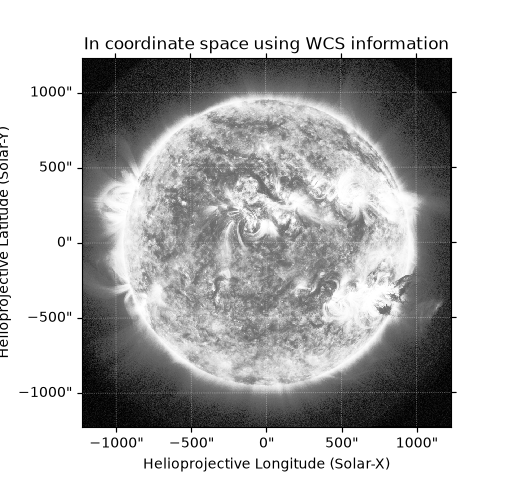
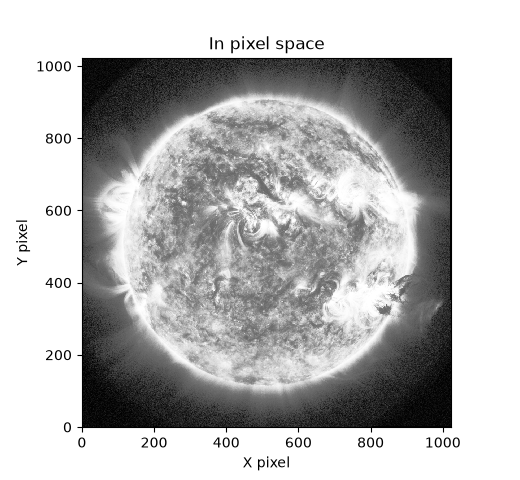
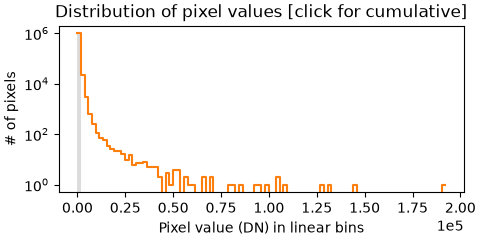
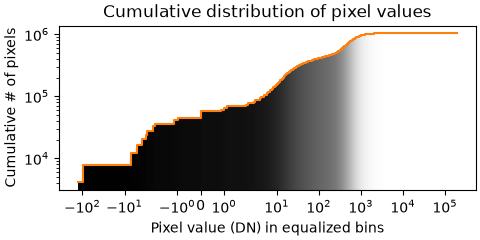

In [3]:
aia_map = sunpy.map.Map(AIA_171_IMAGE)
aia_map

In [4]:
aia_map.meta

MetaDict([('simple': 'True')
('bitpix': '-32')
('naxis': '2')
('naxis1': '1024')
('naxis2': '1024')
('bld_vers': 'V5R12X')
('lvl_num': '1.5')
('t_rec': '2011-06-07T06:33:03Z')
('trecstep': '1.0')
('trecepoc': '1977.01.01_00:00:00_TAI')
('trecroun': '1')
('origin': 'SDO')
('date': '2012-10-16T19:45:34')
('telescop': 'SDO')
('instrume': 'AIA_3')
('date-obs': '2011-06-07T06:33:02.77')
('t_obs': '2011-06-07T06:33:02.88Z')
('camera': '3')
('img_type': 'LIGHT')
('exptime': '0.234256')
('expsdev': '0.000135')
('int_time': '0.507812')
('wavelnth': '171')
('waveunit': 'angstrom')
('wave_str': '171_THIN')
('fsn': '27194331')
('fid': '0')
('quallev0': '0')
('quality': '0')
('totvals': '16777216')
('datavals': '16777216')
('missvals': '0')
('percentd': '100.0')
('datamin': '-8')
('datamax': '17722')
('datamedn': '18')
('datamean': '26.6888')
('datarms': '9429260.0')
('dataskew': '81.433')
('datakurt': '17076.7421875')
('datacent': '30.76')
('datap01': '-1.0')
('datap10': '1.0')
('datap25': '3.0')


In [5]:
print("관측 시각:", aia_map.meta["date-obs"])
print("관측 파장:", aia_map.meta["wavelnth"], aia_map.meta["waveunit"])
print("노출 시간:", aia_map.meta["exptime"], "s")
print("관측기기:", aia_map.meta["telescop"])
print("Instrument:", aia_map.meta["instrume"])

관측 시각: 2011-06-07T06:33:02.77
관측 파장: 171 angstrom
노출 시간: 0.234256 s
관측기기: SDO
Instrument: AIA_3


In [6]:
print("Observation time:", aia_map.meta["date-obs"])
print("Wavelength:", aia_map.meta["wavelnth"], aia_map.meta["waveunit"])
print("Exposure time:", aia_map.meta["exptime"], "s")

print("Pixel scale (x):", aia_map.meta["cdelt1"], aia_map.meta["cunit1"], "/ pixel")
print("Pixel scale (y):", aia_map.meta["cdelt2"], aia_map.meta["cunit2"], "/ pixel")

print("Observed solar radius:", aia_map.meta["rsun_obs"], "arcsec")

print("Telescope:", aia_map.meta["telescop"])
print("Instrument:", aia_map.meta["instrume"])
print("Detector:", aia_map.meta["detector"])

Observation time: 2011-06-07T06:33:02.77
Wavelength: 171 angstrom
Exposure time: 0.234256 s
Pixel scale (x): 2.402792 arcsec / pixel
Pixel scale (y): 2.402792 arcsec / pixel
Observed solar radius: 945.436711 arcsec
Telescope: SDO
Instrument: AIA_3
Detector: AIA


- 실제 분석에서는 SunPy가 현재 Map의 WCS와 관측 거리 등을 해석해 제공하는 다음 속성을 쓰는 편이 안전.

In [7]:
print("Observation time:", aia_map.date)
print("Wavelength:", aia_map.wavelength)
print("Exposure time:", aia_map.exposure_time)
print("Pixel scale:", aia_map.scale)
print("Observed solar radius:", aia_map.rsun_obs)
print("Observatory:", aia_map.observatory)
print("Instrument:", aia_map.instrument)
print("Detector:", aia_map.detector)

Observation time: 2011-06-07T06:33:02.770
Wavelength: 171.0 Angstrom
Exposure time: 0.234256 s
Pixel scale: SpatialPair(axis1=<Quantity 2.402792 arcsec / pix>, axis2=<Quantity 2.402792 arcsec / pix>)
Observed solar radius: 945.436711 arcsec
Observatory: SDO
Instrument: AIA 3
Detector: AIA


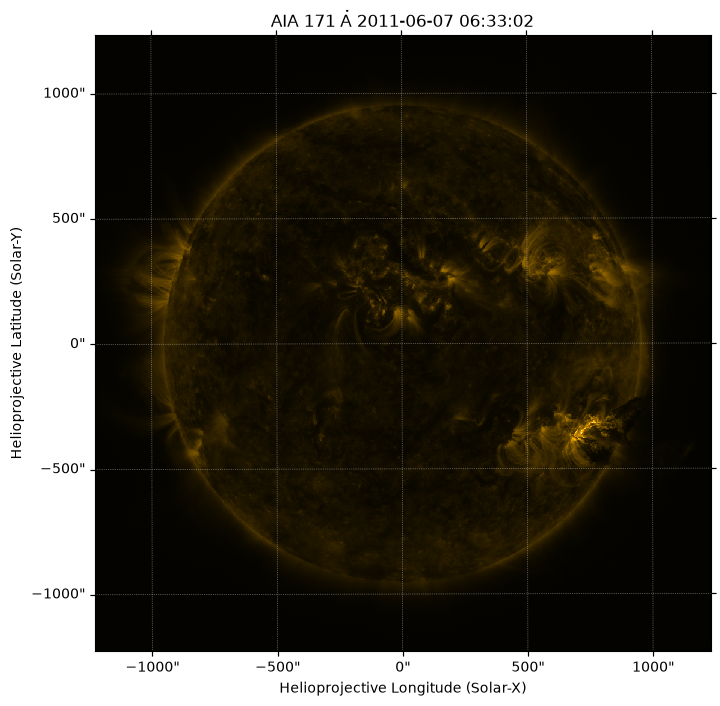

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))

# 일반적인 좌표축이 아니라, aia_map의 WCS 정보를 반영한 태양 좌표축을 생성. 그래서 축이 단순한 pixel 번호가 아니라 helioprojective 좌표로 나타남.
ax = fig.add_subplot(projection=aia_map)

# Map에 저장된 영상 데이터와 기본 컬러맵 및 normalization을 이용해 이미지를 그림.
aia_map.plot(axes=ax)

plt.show()

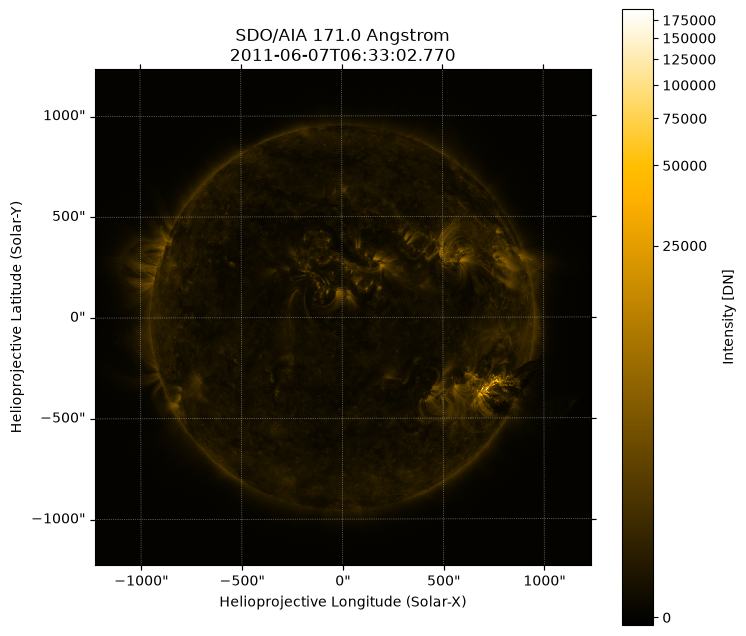

In [10]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=aia_map)

image = aia_map.plot(axes=ax)

ax.set_title(
    f"SDO/AIA {aia_map.wavelength}\n"
    f"{aia_map.date}"
)

fig.colorbar(
    image,
    ax=ax,
    label=f"Intensity [{aia_map.unit}]"
)

plt.show()

- DN은 Data Number로, 검출기가 기록한 디지털 신호값을 뜻함.

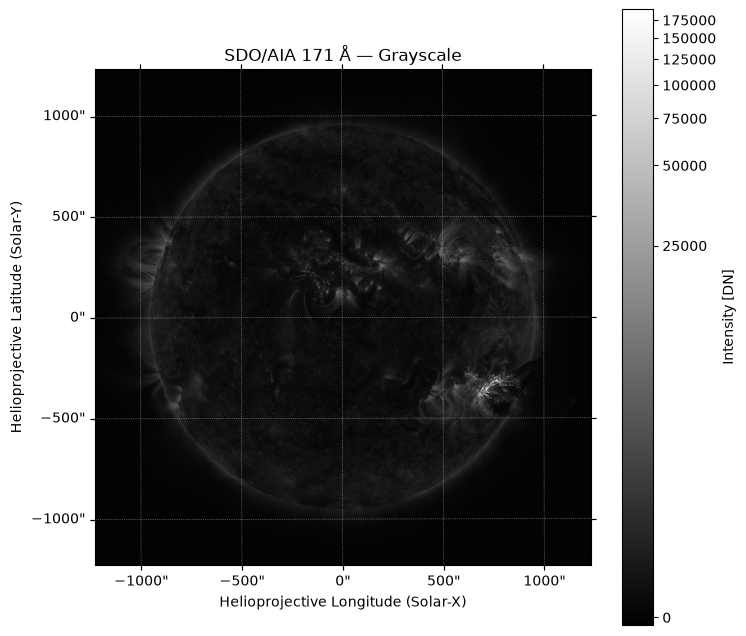

In [12]:
### colormap 바꾸기

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=aia_map)

image = aia_map.plot(
    axes=ax,
    cmap="gray"
)

fig.colorbar(image, ax=ax, label="Intensity [DN]")
ax.set_title("SDO/AIA 171 Å — Grayscale")

plt.show()

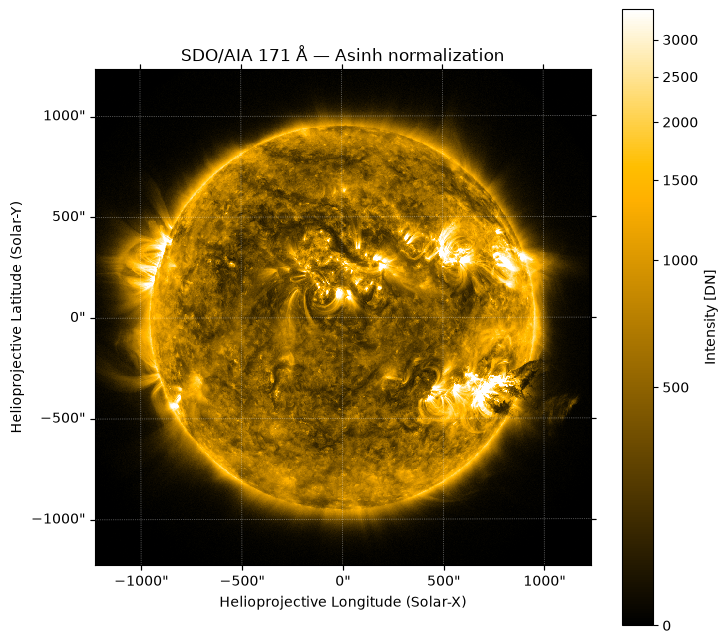

In [14]:
import numpy as np
from astropy.visualization import ImageNormalize, AsinhStretch

vmax = np.nanpercentile(aia_map.data, 99.5)

### intensity normalization 바꾸기

norm = ImageNormalize(
    vmin=0,
    vmax=vmax,
    stretch=AsinhStretch()
)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=aia_map)

image = aia_map.plot(
    axes=ax,
    norm=norm
)

fig.colorbar(image, ax=ax, label="Intensity [DN]")
ax.set_title("SDO/AIA 171 Å — Asinh normalization")

plt.show()

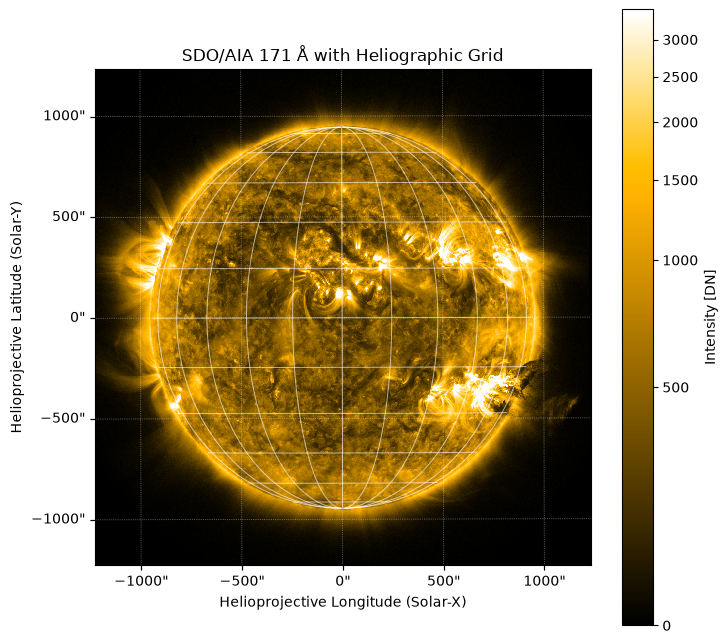

In [21]:
import astropy.units as u

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=aia_map)

image = aia_map.plot(
    axes=ax,
    norm=norm
)

### 태양 표면의 위도·경도 grid를 표시

aia_map.draw_grid(
    axes=ax,
    grid_spacing=15 * u.deg,
    color="white",
    alpha=0.6,
    linewidth=0.7
)

### 가장자리 표시

'''
aia_map.draw_limb(
    axes=ax,
    color="cyan",
    linewidth=1.0
)
'''

fig.colorbar(image, ax=ax, label="Intensity [DN]")
ax.set_title("SDO/AIA 171 Å with Heliographic Grid")

plt.show()

- 그림의 x축과 y축: 관측자에게 보이는 방향을 나타내는 Helioprojective 좌표이며 단위는 arcsec
- 새로 그린 곡선 grid: 태양 표면상의 위치를 나타내는 Heliographic 위도·경도 좌표이며 단위는 degree

In [22]:
### 관심 영역 submap

from astropy.coordinates import SkyCoord
import astropy.units as u

bottom_left = SkyCoord(
    450 * u.arcsec,
    -650 * u.arcsec,
    frame=aia_map.coordinate_frame
)

top_right = SkyCoord(
    950 * u.arcsec,
    -150 * u.arcsec,
    frame=aia_map.coordinate_frame
)

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2011-06-07 06:33:02
Exposure Time,0.234256 s
Dimension,[209. 209.] pix
Coordinate System,helioprojective
Scale,[2.402792 2.402792] arcsec / pix
Reference Pixel,[-186.5 270.5] pix

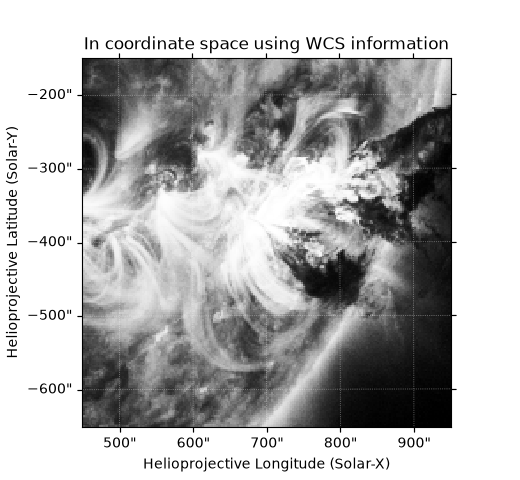
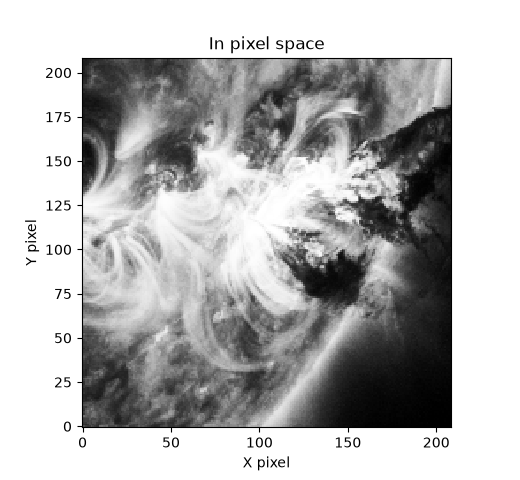
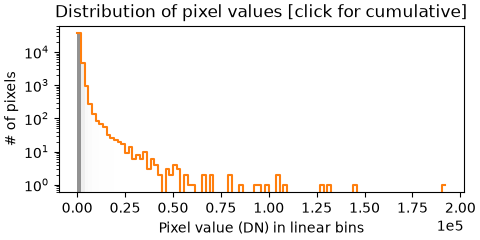
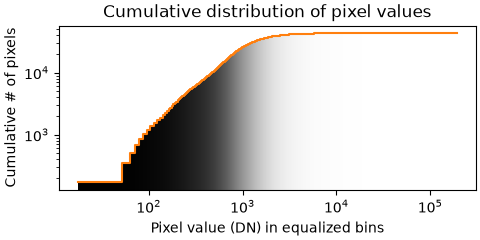

In [23]:
aia_submap = aia_map.submap(
    bottom_left,
    top_right=top_right
)

aia_submap

In [24]:
print("Original map:", aia_map.dimensions)
print("Submap:", aia_submap.dimensions)

Original map: PixelPair(x=<Quantity 1024. pix>, y=<Quantity 1024. pix>)
Submap: PixelPair(x=<Quantity 209. pix>, y=<Quantity 209. pix>)


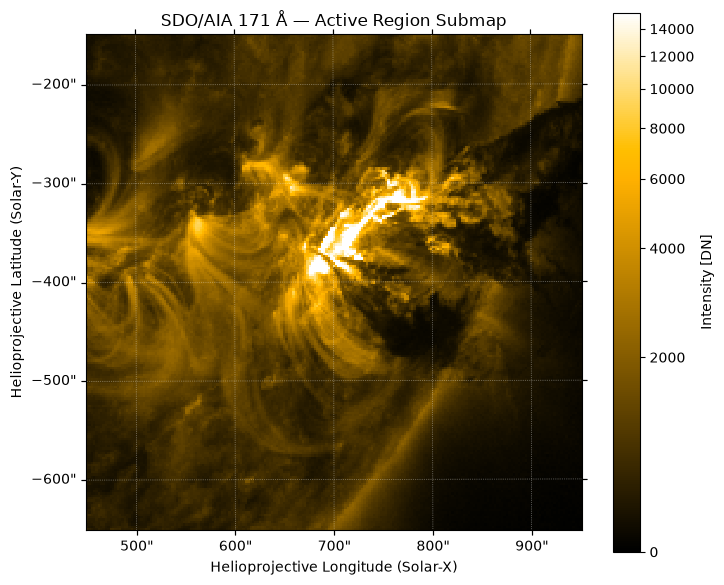

In [25]:
submap_vmax = np.nanpercentile(aia_submap.data, 99.5)

submap_norm = ImageNormalize(
    vmin=0,
    vmax=submap_vmax,
    stretch=AsinhStretch()
)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection=aia_submap)

image = aia_submap.plot(
    axes=ax,
    norm=submap_norm
)

fig.colorbar(image, ax=ax, label="Intensity [DN]")
ax.set_title("SDO/AIA 171 Å — Active Region Submap")

plt.show()

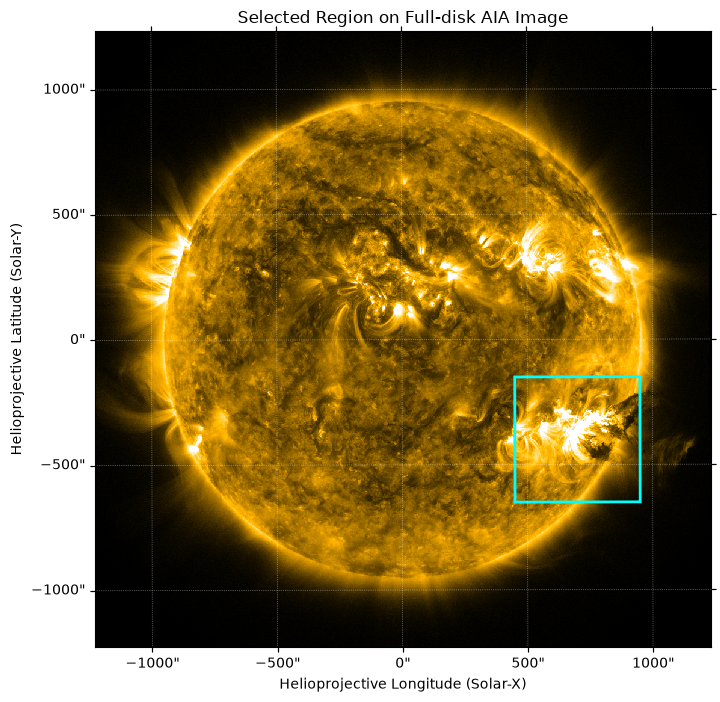

In [26]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=aia_map)

aia_map.plot(axes=ax, norm=norm)

aia_map.draw_quadrangle(
    bottom_left,
    top_right=top_right,
    axes=ax,
    edgecolor="cyan",
    linewidth=2
)

ax.set_title("Selected Region on Full-disk AIA Image")

plt.show()

In [27]:
### pixel 좌표 -> 태양 좌표

x_pixel = 150 * u.pix
y_pixel = 100 * u.pix

solar_coord = aia_submap.pixel_to_world(
    x_pixel,
    y_pixel
)

print(solar_coord)
print("Solar-X:", solar_coord.Tx)
print("Solar-Y:", solar_coord.Ty)

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.880, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.880, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406429, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (810.76344372, -410.24446953)>
Solar-X: 810.763 arcsec
Solar-Y: -410.244 arcsec


In [29]:
### numpy 배열에서 값을 읽을 때는 x-y 순서가 반대

intensity = aia_submap.data[
    int(y_pixel.value),
    int(x_pixel.value)
]

print("Pixel intensity:", intensity, aia_submap.unit)

Pixel intensity: 1525.0356 DN


In [30]:
### 태양 좌표 -> pixel 좌표

pixel_coord = aia_submap.world_to_pixel(solar_coord)

print("x pixel:", pixel_coord.x)
print("y pixel:", pixel_coord.y)

x pixel: 150.00000000001558 pix
y pixel: 99.99999999999207 pix


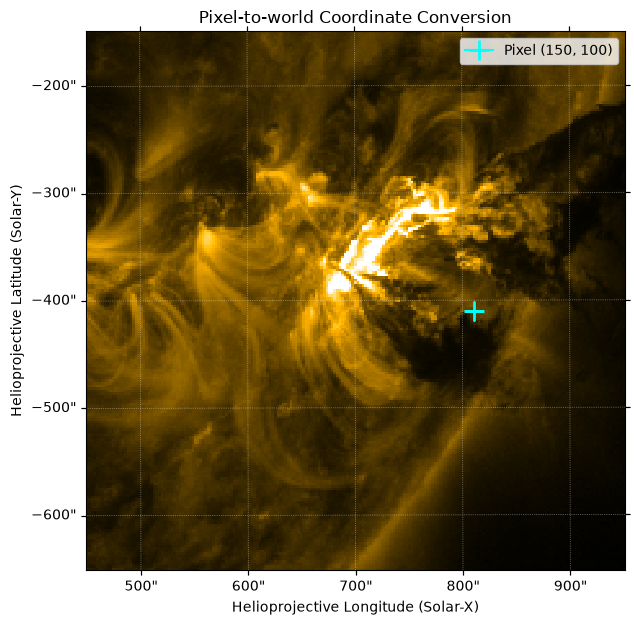

In [31]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection=aia_submap)

aia_submap.plot(
    axes=ax,
    norm=submap_norm
)

ax.plot_coord(
    solar_coord,
    marker="+",
    color="cyan",
    markersize=15,
    markeredgewidth=2,
    label=f"Pixel ({x_pixel.value:.0f}, {y_pixel.value:.0f})"
)

ax.legend()
ax.set_title("Pixel-to-world Coordinate Conversion")

plt.show()

### 3. 데이터 다운로드

- Fido: 여러 태양 관측 데이터 서비스를 통합해서 검색·다운로드하는 인터페이스
- attrs as a: 날짜, 관측기기, 파장 등의 검색 조건을 만드는 도구

In [32]:
from sunpy.net import Fido, attrs as a
import astropy.units as u

In [39]:
time_range = a.Time(
    "2011-06-07 06:33:00",
    "2011-06-07 06:33:05"
)

instrument = a.Instrument.aia
wavelength = a.Wavelength(171 * u.angstrom)

In [40]:
print(time_range)
print(instrument)
print(wavelength)

<sunpy.net.attrs.Time(2011-06-07 06:33:00.000, 2011-06-07 06:33:05.000)>
<sunpy.net.attrs.Instrument(AIA: Data from the Atmospheric Imaging Assembly instrument.) object at
0x1144ae990>
<sunpy.net.attrs.Wavelength(171.0, 171.0, 'Angstrom')>


In [41]:
search_result = Fido.search(
    time_range,
    instrument,
    wavelength
)

search_result

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2011-06-07 06:33:02.000,2011-06-07 06:33:03.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


In [42]:
print("검색 결과 묶음 수:", len(search_result))
print("전체 파일 수:", search_result.file_num)
print("첫 번째 결과표의 행 수:", len(search_result[0]))

검색 결과 묶음 수: 1
전체 파일 수: 1
첫 번째 결과표의 행 수: 1


In [43]:
file_sizes = search_result[0]["Size"]

print("각 파일의 예상 용량:")
print(file_sizes)

print("총 예상 용량:", file_sizes.sum())

각 파일의 예상 용량:
[64.64844] Mibyte
총 예상 용량: 64.64844 Mibyte


In [44]:
from pathlib import Path

download_dir = Path("../data/aia")

downloaded_files = Fido.fetch(
    search_result,
    path=download_dir / "{file}"
)

downloaded_files

Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]2026-08-17 16:13:09 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617 failed to download with exception
Timeout on reading data from socket
Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]

1/0 files failed to download. Please check `.errors` for details


[]
Errors:
(<parfive.results.Error object at 0x135bf7ad0>
https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617,
Timeout on reading data from socket)

In [47]:
import aiohttp
from parfive import Downloader, SessionConfig

timeouts = aiohttp.ClientTimeout(
    total=None,       # 전체 다운로드 시간에는 제한 없음
    sock_connect=60,  # 서버 연결은 최대 60초 대기
    sock_read=600     # 데이터가 멈춰도 최대 10분 대기
)

config = SessionConfig(timeouts=timeouts)

custom_downloader = Downloader(
    max_conn=1,
    max_splits=1,
    config=config
)

In [48]:
downloaded_files = Fido.fetch(
    search_result,
    path=download_dir / "{file}",
    downloader=custom_downloader
)

downloaded_files

Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [00:00<?, ?file/s]
aia.lev1.171A_2011_06_07T06_33_02.77Z.image_lev1.fits:   0%|                                                                                                                            | 0.00/9.46M [00:00<?, ?B/s]
Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [10:49<?, ?file/s]2026-08-17 16:42:23 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617 failed to download with exception
<ClientResponse(https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617) [500 Internal Server Error]>
<CIMultiDi

1/0 files failed to download. Please check `.errors` for details


[]
Errors:
(<parfive.results.Error object at 0x137b62f30>
https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617,
<ClientResponse(https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503617-1086503617) [500 Internal Server Error]>
<CIMultiDictProxy('Date': 'Mon, 17 Aug 2026 07:37:11 GMT', 'Server': 'Apache', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains', 'Content-Length': '541', 'Connection': 'close', 'Content-Type': 'text/html; charset=iso-8859-1')>
)

### Download attempt

- Query: 2011-06-07 06:33:00–06:33:05
- Instrument: SDO/AIA
- Wavelength: 171 Å
- Search client: VSOClient
- Provider: JSOC
- Result: 1 file, 64.65 MiB
- Download URL: sdo7.nascom.nasa.gov
- Status: Failed
- Error: HTTP 500 Internal Server Error from the remote server

In [49]:
from getpass import getpass

jsoc_email = getpass("JSOC registered email: ")

JSOC registered email:  ········


In [50]:
jsoc_result = Fido.search(
    a.Time(
        "2011-06-07 06:33:00",
        "2011-06-07 06:33:05"
    ),
    a.jsoc.Series("aia.lev1_euv_12s"),
    a.jsoc.Segment("image"),
    a.Wavelength(171 * u.angstrom),
    a.jsoc.Notify(jsoc_email)
)

jsoc_result

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str20,str7,str5,int64,int64
2011-06-07T06:33:02Z,SDO/AIA,AIA_3,171,2111


In [51]:
jsoc_downloader = Downloader(
    max_conn=1,
    max_splits=1,
    config=config
)

downloaded_files = Fido.fetch(
    jsoc_result,
    path=download_dir / "{file}",
    downloader=jsoc_downloader
)

downloaded_files

2026-08-17 17:20:03 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=2]
2026-08-17 17:20:03 - drms - INFO: Waiting for 5 seconds...
2026-08-17 17:20:08 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=1]
2026-08-17 17:20:08 - drms - INFO: Waiting for 10 seconds...
2026-08-17 17:20:19 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=1]
2026-08-17 17:20:19 - drms - INFO: Waiting for 10 seconds...
2026-08-17 17:20:30 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=1]
2026-08-17 17:20:30 - drms - INFO: Waiting for 10 seconds...
2026-08-17 17:20:40 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=1]
2026-08-17 17:20:40 - drms - INFO: Waiting for 10 seconds...
2026-08-17 17:20:51 - drms - INFO: Export request pending. [id=JSOC_20260817_004170, status=1]
2026-08-17 17:20:51 - drms - INFO: Waiting for 10 seconds...
2026-08-17 17:21:02 - drms - INFO: Export request pending. [id=JS

INFO: 1 URLs found for download. Full request totaling 12MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [00:00<?, ?file/s]
aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits:   0%|                                                                                                                          | 0.00/12.3M [00:00<?, ?B/s]
aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits:   0%|                                                                                                               | 1.02k/12.3M [00:00<3:03:07, 1.12kB/s]
aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits:   0%|▎                                                                                                                | 33.4k/12.3M [00:01<04:51, 42.3kB/s]
aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits:   1%|▉                                                                                     

['../data/aia/aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits']

In [52]:
print("다운로드 파일 수:", len(downloaded_files))
print("오류:", downloaded_files.errors)

for file_path in downloaded_files:
    print(file_path)

다운로드 파일 수: 1
오류: []
../data/aia/aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits


- VSO 경유 export 실패
- JSOC 직접 export 성공

In [53]:
### 다운로드 경로와 실제 용량 확인

download_path = Path(downloaded_files[0]).resolve()

print("절대 경로:", download_path)
print("파일 용량:", download_path.stat().st_size / 1024**2, "MiB")

절대 경로: /Users/jyson/SunProject/data/aia/aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits
파일 용량: 11.76910400390625 MiB


Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2011-06-07 06:33:12
Exposure Time,1.9996379999999998 s
Dimension,[4096. 4096.] pix
Coordinate System,helioprojective
Scale,[0.59948897 0.59948897] arcsec / pix
Reference Pixel,[2049.45996 2049.03003] pix

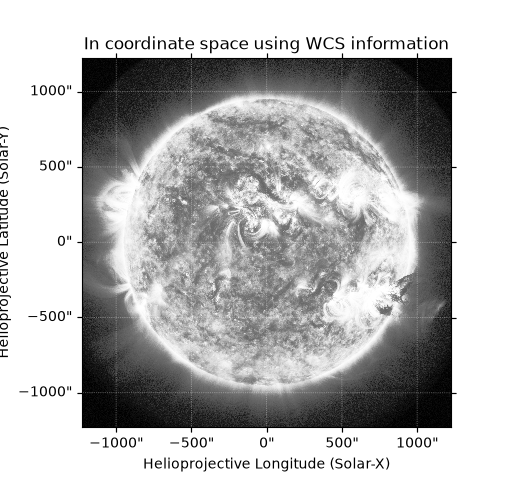
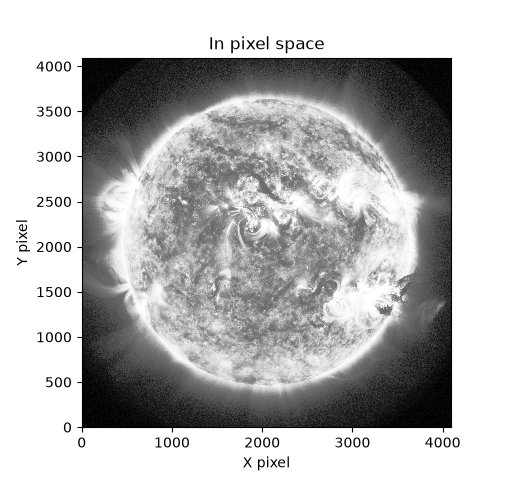
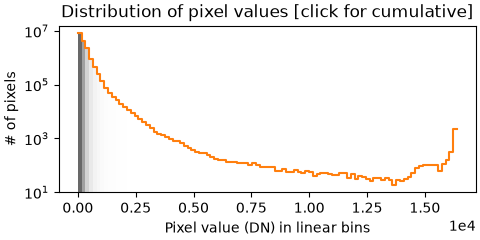
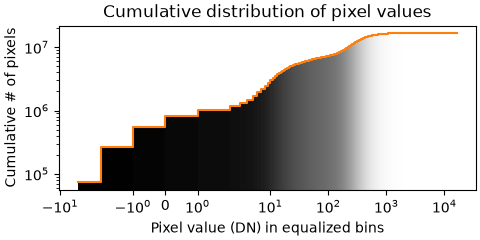

In [54]:
### FITS 파일을 SunPy Map으로 열기

downloaded_map = sunpy.map.Map(downloaded_files[0])

downloaded_map

In [55]:
print("관측 시각:", downloaded_map.date)
print("관측기기:", downloaded_map.instrument)
print("관측 파장:", downloaded_map.wavelength)
print("영상 크기:", downloaded_map.dimensions)
print("Pixel scale:", downloaded_map.scale)
print("Exposure time:", downloaded_map.exposure_time)

관측 시각: 2011-06-07T06:33:12.344
관측기기: AIA 3
관측 파장: 171.0 Angstrom
영상 크기: PixelPair(x=<Quantity 4096. pix>, y=<Quantity 4096. pix>)
Pixel scale: SpatialPair(axis1=<Quantity 0.59948897 arcsec / pix>, axis2=<Quantity 0.59948897 arcsec / pix>)
Exposure time: 1.9996379999999998 s


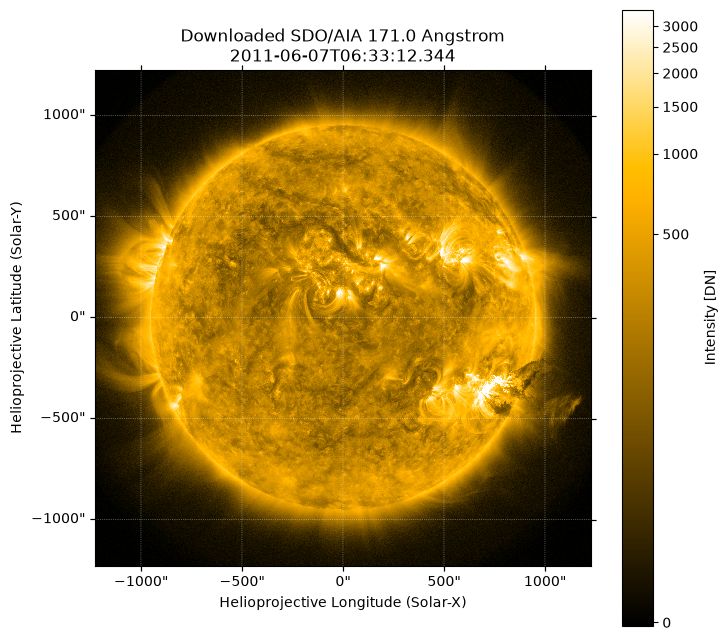

In [56]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=downloaded_map)

image = downloaded_map.plot(
    axes=ax,
    clip_interval=(1, 99.9) * u.percent
)

fig.colorbar(
    image,
    ax=ax,
    label=f"Intensity [{downloaded_map.unit}]"
)

ax.set_title(
    f"Downloaded SDO/AIA {downloaded_map.wavelength}\n"
    f"{downloaded_map.date}"
)

plt.show()

### AIA data query and download

- Time range: 2011-06-07 06:33:00–06:33:05 UTC
- Instrument: SDO/AIA
- Wavelength: 171 Å
- JSOC series: `aia.lev1_euv_12s`
- Segment: `image`
- Search result: 1 record
- Download method: JSOCClient staged export
- Download path: `../data/aia/`
- File: `aia.lev1_euv_12s.2011-06-07T063313Z.171.image_lev1.fits`
- Initial VSO download: failed with timeout/HTTP 500
- JSOC staged download: successful